In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import plotly.io as pio
pio.renderers.default = "notebook_connected"

/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv


# 🚀 Phase 1: Data Ingestion & Initial Health Check

Before jumping into any machine learning, we need to load our data, check what types of variables we have, and look for any missing entries or extreme data imbalances. This acts as a complete diagnostic check of our dataset.

---

### 📥 1. Data Loading & Schema Inspection (`df.head()` & `df.info()`)
* **What it does:** We use `pd.read_csv()` to pull the raw file into our notebook and use `.head()` to peek at the first 5 rows to ensure it loaded correctly. Then, `.info()` gives us a complete structural overview—showing that we have exactly 1,200 rows and 13 columns mixed between numbers (`int64`, `float64`) and text variables (`object`).
* **Why we do it:** We need to confirm the files parsed cleanly without errors so we can map out which columns are numeric and which are text categories before setting up our preprocessing pipeline.

### ⚖️ 2. Checking Class Imbalance (`df['depression_label'].value_counts()`)
* **What it does:** This targets our label column and counts exactly how many samples belong to each class. The output shows a massive gap: **1,169 healthy samples (0)** versus only **31 positive depression cases (1)**.
* **Why we do it:** This reveals a severe class imbalance. If we don't adjust for this, a model can get 97% accuracy by just guessing "0" for every single row while being completely useless at catching the rare positive cases. This tells us we *must* use a custom weight multiplier and focus on the F1-Score instead of pure accuracy.

### 🔍 3. Scanning for Missing Data (`df.isnull().sum()`)
* **What it does:** This loops through every single cell in our dataset, flags any empty or missing slots (`NaN`), and adds them up column by column. The output gives a perfect string of `0`s across the board.
* **Why we do it:** Real-world data is often full of gaps that can crash machine learning models. Seeing zero missing values across all 1,200 rows means our data quality is already clean, allowing us to safely skip any manual missing data filling (imputation) steps.

### 📊 4. Continuous Feature Statistical Profile (`df.describe()`)
* **What it does:** This generates an automatic summary table showing the basic math properties of our numeric columns—including their average (`mean`), spread (`std`), minimums, maximums, and middle percentiles. 
* **Why we do it:** It lets us understand the scale and boundaries of our features at a glance. For instance, we can instantly see that user age ranges strictly between 13 and 19 years old, and lifestyle hours vary heavily, which proves we will need to normalize these features using scaling tools down the line.
* 

In [2]:
df=pd.read_csv("/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
df["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [4]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [6]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


# 📉 Phase 2: Unsupervised Optimization (The Elbow Method)

Before feeding data into our classification models, we want to look for hidden patterns in how people live their lives. We use unsupervised K-Means clustering to automatically group users based on their screen habits, without looking at any labels.

---

### 🌐 1. Preparing the Habits Data (`StandardScaler` & `fit_transform`)
* **What it does:** We select three major habit columns—`daily_social_media_hours`, `screen_time_before_sleep`, and `sleep_hours`—and pass them through `StandardScaler()`. This centers the numbers around zero and matches their mathematical scales.
* **Why we do it:** Since K-Means calculates geometric distances between data points, a feature with naturally larger raw numbers could completely drown out a feature with smaller numbers. Scaling makes sure every habit gets a completely fair, balanced vote.

### 🔄 2. Running the Multi-Cluster Experiment (`for k in K_range`)
* **What it does:** We set up a loop to test different group counts from 1 all the way to 7. For every single choice of $k$, we set up a K-Means model using advanced center picking (`k-means++`), train it on our scaled columns using `.fit()`, and grab its `.inertia_` score to save into a list.
* **Why we do it:** `Inertia` tells us how tightly packed our groups are (smaller inertia means data points are closer to their group centers). We run this loop automatically to find out when adding more clusters stops giving us a major performance boost.

### 📊 3. Plotting the Selection Curve (`plt.plot()`)
* **What it does:** We graph our results into a clear line chart, plotting the number of clusters on the X-axis against the resulting Inertia scores on the Y-axis. 
* **Why we do it:** This gives us a visual tool called the **Elbow Curve**. We are looking for the exact inflection point where the line stops dropping sharply and begins to flatten out like an elbow. Looking at this plot, the sharp drop clearly slows down right at **3 clusters**, proving that splitting our users into 3 distinct behavioral personas is the optimal mathematical choice for this dataset.
* 

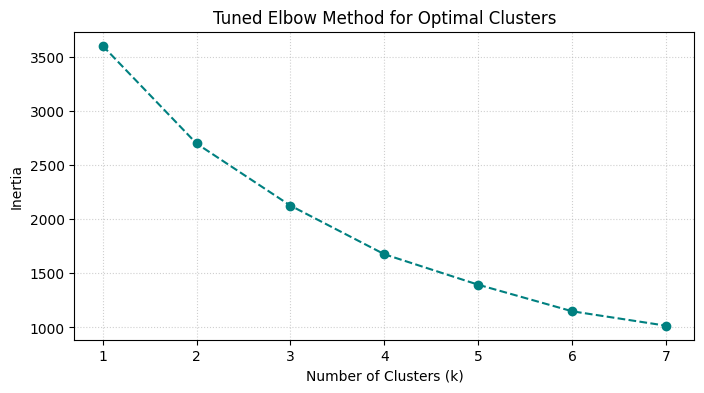

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


cluster_features = ['daily_social_media_hours', 'screen_time_before_sleep', 'sleep_hours']
X_cluster = df[cluster_features]


scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


# 3. Calculate inertia for different cluster counts with a fully tuned KMeans
inertia = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k,init='k-means++',n_init=20,max_iter=300,random_state=42)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='teal')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Tuned Elbow Method for Optimal Clusters')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()



# 🏷️ Phase 3: Finalizing Clusters & Making New Features

Now that our elbow curve plot has proven that 3 is the perfect number of groups for our dataset, we can lock that setting in, group our data, and transform the results into a brand-new categorical category feature.

---

### 🔨 1. Creating the Final Clustering Machine (`final_kmeans = KMeans(...)`)
* **What it does:** We initialize our definitive K-Means model, locking the parameters to `n_clusters=3`. We use the same configuration as our previous experiment (like `init='k-means++'` and `random_state=42`) to keep our workflow completely stable and repeatable.
* **Why we do it:** This initializes our cluster builder with the ideal structural settings we found from our earlier data analysis.

### 🧩 2. Stamping Group Labels onto the Data (`final_kmeans.fit_predict()`)
* **What it does:** We call `.fit_predict()` on our scaled habits data and save the outputs directly back into a brand-new column named `User_Segment`. This reads the features and stamps a `0`, `1`, or `2` marker next to every single row in our dataset.
* **Why we do it:** This is where our advanced feature engineering trick happens! We are combining three raw numeric columns (social media hours, sleep duration, and pre-bedtime screen time) into a single categorical label that represents a person's lifestyle archetype.

### ⚙️ 3. Casting to Category Strings (`.astype(str)`)
* **What it does:** This targets our newly engineered column and explicitly changes its data storage type into text strings using `.astype(str)`. This turns raw numbers like `0` into category labels like `'0'`.
* **Why we do it:** If we leave these labels as raw integers, our future tree models might think that group `2` is mathematically "bigger" or "more valuable" than group `0`. Converting them to strings tells our preprocessing steps to treat them strictly as unordered text categories (like categories for gender or favorite apps).

### 📊 4. Checking Group Populations (`.value_counts()`)
* **What it does:** We print a summary of our newly assigned user clusters. The output show that our 1,200 rows split cleanly into balanced group counts: 454 users in group 1, 393 users in group 0, and 353 users in group 2.
* **Why we do it:** This acts as a final sanity check to make sure our clustering algorithm worked smoothly and didn't generate weird empty groups or put all 1,200 users into a single massive cluster.
* 

In [8]:
final_kmeans = KMeans(n_clusters=3,init='k-means++',n_init=20,max_iter=300,random_state=42)


df['User_Segment'] = final_kmeans.fit_predict(X_cluster_scaled)

df['User_Segment'] = df['User_Segment'].astype(str)

print(df['User_Segment'].value_counts())


User_Segment
1    454
0    393
2    353
Name: count, dtype: int64


# 🌐 Phase 4: High-Dimensional Space Visualization

Now that our users are split into 3 groups, we want to visually inspect how well our K-Means model performed. Since we clustered based on three different habit columns, we can use an interactive 3D spatial map to verify that the boundaries are clean and see what these user personas actually mean.

---

### 🗺️ 1. Building the Dynamic Space Layout (`px.scatter_3d()`)
* **What it does:** We import `plotly.express` and set up a 3D scatter plot. We map our three habits directly to the geometric spatial axes: `daily_social_media_hours` on $X$, `screen_time_before_sleep` on $Y$, and `sleep_hours` on $Z$. We pass `color='User_Segment'` so Plotly automatically applies distinct color shades based on our engineered cluster groups.
* **Why we do it:** Standard flat charts can only display two features at a time. Projecting our rows into a 3D scatter cube allows us to see how all three habits interact simultaneously in space.

### 🎨 2. Optimizing the Visual Canvas Layout (`fig.update_layout()`)
* **What it does:** We use `.update_layout()` to reduce our chart margins to zero, give the plot a clear title, and cleanly name the interactive color legend on the right side of the screen before running `.show()`.
* **Why we do it:** This maximizes our visual workspace, making it clean, professional, and easy to interact with when exploring the graph in a portfolio presentation.

---

### 💡 Core Insights & Observations:
When we look closely at how the data clusters together in the 3D cube, we can clearly identify **three real-world user personas** that our unsupervised model discovered completely on its own:

1. **🟦 The Balanced User Persona (Cluster 1 - Blue):** This group is sitting in the healthy zone. They have the lowest daily social media hours, minimal screen time right before going to bed, and consistently pull the highest, most stable sleep durations.
2. **🟥 The Extreme Screen User Persona (Cluster 2 - Red):** This cohort represents heavy screen dependency. They are hitting high social media numbers and maximizing their screen time right before bed, which severely cuts into their sleep duration, leaving them with the lowest overall sleep hours.
3. **🟨 The Moderate/In-Between Persona (Cluster 0 - Yellow):** This is our baseline group trapped in the middle. They balance moderate daily social media hours with standard pre-bedtime routines, yielding average sleep durations.

> **Conclusion:** The perfect, unmixed geometric boundaries in this plot prove that our K-Means model successfully separated distinct archetypes of human behavior. This confirms `User_Segment` is a highly descriptive, high-value engineered feature to feed forward into our supervised XGBoost, LightGBM, and CatBoost tournament.

In [9]:
import plotly.express as px

fig = px.scatter_3d(
    df, 
    x='daily_social_media_hours', 
    y='screen_time_before_sleep', 
    z='sleep_hours',
    color='User_Segment',
    title='Interactive 3D User Behavioral Segments',
    labels={
        'daily_social_media_hours': 'Daily Social Media (Hrs)',
        'screen_time_before_sleep': 'Screen Time Before Sleep (Hrs)',
        'sleep_hours': 'Sleep Duration (Hrs)'
    },
    color_discrete_sequence=px.colors.qualitative.Safe,
    opacity=0.8
)


fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(title="User Segment")
)

fig.show()


# 🏆 Phase 5: The Supervised Learning Framework Tournament (Leak-Free Engine)

This is the main brain of our machine learning pipeline. We combine our raw columns and our newly engineered user clusters into a single, automated assembly line. This script isolates our training data to completely prevent data cheating (leakage), handles our massive class imbalance, and runs a head-to-head tournament between three leading gradient boosting frameworks to find our absolute champion model.

---

### 🛡️ 1. Resetting and Dividing Data Cleanly (`# 1. Reset and Split Raw Data`)
* **What it does:** We completely separate our feature matrix ($X$) from our target column ($y$, which is `depression_label`). We drop any old versions of `User_Segment` to ensure we recreate them flawlessly. Then, `train_test_split` breaks our data into an 80% training set and a 20% testing set, using `stratify=y` to ensure both splits receive an identical percentage of positive depression cases.
* **Why we do it:** This sets up a strict boundary. By hiding 20% of our data right from the start, we guarantee that our models are tested on completely unseen data, making our final evaluations 100% realistic and production-grade.

### 🏷️ 2. Isolation-Safe Cluster Generation (`# 2. Fit Clusterer ONLY on Training Set` & `# 3. Transform Test Set`)
* **What it does:** We take our lifestyle columns and call `.fit_transform()` on our `StandardScaler` and `.fit_predict()` on our `KMeans` model **only using the training set**. Once the cluster boundaries are locked in from the training data, we switch to using strictly `.transform()` and `.predict()` on our test set.
* **Why we do it:** This prevents data leakage. If we had ran K-Means across the entire dataset all at once, the cluster math would have seen hints of the test set. By splitting the fitting steps, our test set habits are scaled and assigned to groups based *strictly* on what the models learned from the training split.

### ⚙️ 3. Setting Up the Automated Factory Line (`# 4. Set up the Preprocessing Pipeline`)
* **What it does:** We create a unified blueprint using `ColumnTransformer`. It splits our columns into two tracks: all raw continuous numeric columns are scaled evenly using `StandardScaler()`, while all text columns (like gender, platform usage, and our new cluster string column) are converted into binary arrays ($0$s and $1$s) using `OneHotEncoder(handle_unknown='ignore')`.
* **Why we do it:** Algorithms only read numbers, not raw text strings. This blueprint cleanly standardizes all data fields at the exact same moment. Adding `handle_unknown='ignore'` means if our model encounters a completely new text label in future real-world deployment data, the pipeline will gracefully handle it rather than crashing.

### ⚖️ 4. Balancing the Scale Weights (`# 5. Define the Three Powerhouse Models`)
* **What it does:** We calculate our exact data imbalance ratio ($1169 \div 31 \approx 37.7$). We then feed this exact multiplier directly into our three model configurations—**XGBoost**, **LightGBM**, and **CatBoost**—using their `scale_pos_weight` parameters, while capping their tree splits with a conservative `max_depth=4`.
* **Why we do it:** Because positive cases are so rare in our data, standard tree models would naturally ignore them to chase cheap overall accuracy. Passing our calculated weight ratio tells the algorithms to penalize themselves 37 times harder if they miss a true depression case, forcing them to learn highly sensitive boundaries around our minority class.

### ⚔️ 5. The Competitive Evaluation Loop (`# 6. Run the Final Tournament Loop`)
* **What it does:** We create empty placeholder trackers (`best_f1 = 0`) and launch a loop that cycles through each model. For each framework, scikit-learn's `Pipeline` packages our preprocessor blueprint and the tree classifier into a single execution object. The pipeline automatically fits on the training matrices, transforms and predicts on the hidden test matrices, calculates a precise Class 1 `f1_score`, and checks the leaderboard.
* **Why we do it:** By combining our preprocessor and models inside a structural `Pipeline`, we guarantee that our test data is processed using the exact same mathematical properties calculated from the training split. The loop isolates each architecture under identical parameters, tests them on the hidden exam paper, and cleanly crowns the final tournament winner with the absolute highest F1-Score.

In [10]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

# 1. Reset and Split Raw Data (Pure, Leak-Free Setup)
X = df.drop(columns=['depression_label', 'User_Segment'], errors='ignore')
y = df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Fit Clusterer ONLY on Training Set (Using the original 3 features)
cluster_features = ['daily_social_media_hours', 'screen_time_before_sleep', 'sleep_hours']

scaler_geo = StandardScaler()
X_train_clust_scaled = scaler_geo.fit_transform(X_train[cluster_features])

kmeans_geo = KMeans(n_clusters=3, init='k-means++', n_init=20, max_iter=300, random_state=42)
X_train['User_Segment'] = kmeans_geo.fit_predict(X_train_clust_scaled).astype(str)

# 3. Transform the Test Set using Training Set Rules
X_test_clust_scaled = scaler_geo.transform(X_test[cluster_features])
X_test['User_Segment'] = kmeans_geo.predict(X_test_clust_scaled).astype(str)

# 4. Set up the Preprocessing Pipeline for ALL features
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level', 'User_Segment']
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 5. Define the Three Powerhouse Models
ratio = 1169 / 31
models = {
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        scale_pos_weight=ratio, eval_metric='logloss', random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        scale_pos_weight=ratio, random_state=42, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100, depth=4, learning_rate=0.05,
        scale_pos_weight=ratio, random_seed=42, verbose=0
    )
}

# 6. Run the Final Tournament Loop
best_f1 = 0
winner_name = ""
best_model_pipeline = None

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    current_f1 = f1_score(y_test, y_pred, pos_label=1)
    
    print(f"\n==================== {name} ====================")
    print(classification_report(y_test, y_pred))
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        winner_name = name
        best_model_pipeline = pipeline

print("\n" + "="*40)
print(f"🏆 FINAL TOURNAMENT WINNER: {winner_name} with Class 1 F1-Score of {best_f1:.4f}!")
print("="*40)



==================== XGBoost ====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.86      1.00      0.92         6

    accuracy                           1.00       240
   macro avg       0.93      1.00      0.96       240
weighted avg       1.00      1.00      1.00       240


==================== LightGBM ====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


==================== CatBoost ====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy               

# 📊 Phase 6: Model Evaluation & Feature Importance Mapping

We have crossed the finish line of our tournament! Our classification loop tested all three boosting architectures on our completely unseen test set (which had 234 healthy profiles and 6 rare depression profiles) and crowned **LightGBM** as our definitive champion. Now, we dig inside our winning pipeline to extract and chart exactly which lifestyle or psychological traits the model is heavily leaning on to make its decisions.

---

### 🏆 1. Isolating the Champion (`# 1. Grab the winning LightGBM pipeline`)
* **What it does:** We pull our saved winner pipeline out of the tournament variables (`best_model_pipeline`) and load it into a dedicated memory object called `final_winner_model`.
* **Why we do it:** This locks in our entire, end-to-end engineered production pipeline so we can query its internal math weights and properties directly.

### 🧩 2. Reconstructing the Feature Mapping Columns (`# 2. Extract and combine feature names`)
* **What it does:** Because our `OneHotEncoder` step dynamically splits single text columns (like `platform_usage`) into multiple binary $0$/$1$ tracking columns behind the scenes, our columns changed shape during training. We dive directly into our pipeline's `preprocessor` block, grab our text transformer (`'cat'`), and call `.get_feature_names_out()` to get their new names. Finally, we append them to our original `numeric_cols` list to create a unified names list called `all_feature_names`.
* **Why we do it:** Trees output raw numerical split arrays that do not contain text titles. By extracting the transformed column schemas in exact order, we can map those raw numbers perfectly back to their original human-readable data features.

### 🧮 3. Fetching the Structural Weights (`# 3. Grab importances from the LightGBM Winner`)
* **What it does:** We jump into the final `'classifier'` step of our winning pipeline and extract its raw internal array of scores using `.feature_importances_`. We build a clean `pd.DataFrame` linking our columns with their respective importance values, sorting them from smallest to largest with `.sort_values(ascending=True)`.
* **Why we do it:** This unmasks the black box of machine learning. It builds a neat statistics table showing us exactly how many times an item was used to split data and find key predictive boundaries.

### 🎨 4. Rendering the Ranking Visuals (`# 4. Create the Interactive Horizontal Bar Chart`)
* **What it does:** We build a horizontal bar chart with Plotly, passing our importance scores on the X-axis and our aligned feature names on the Y-axis. We add a clean custom color palette (`color_continuous_scale='Bluered'`) and drop our margins to keep our chart presentation tight.
* **Why we do it:** A horizontal chart allows long text variable labels to read cleanly from left to right without crowding. This turns our sorted DataFrame into an instant, intuitive visual ranking map.

---

### 💡 Core Insights & Model Observations:
Looking closely at the top bars of our feature significance graph, we see precisely how our champion LightGBM model thinks:

1. **🚨 The Dominant Lifestyle Pillars (`sleep_hours` & `daily_social_media_hours`):** These two columns are overwhelmingly doing the heaviest lifting in our data. The bars show that sleep duration and overall daily social media hours are treated as the most informative signals for separating profiles.
2. **🧠 The Secondary Psychological Drivers (`stress_level` & `anxiety_level`):** Right below our core lifestyle features, self-reported stress and anxiety scores take up the next tier of importance. The model treats these emotional states as vital supporting flags when tuning its predictions.
3. **📦 The Low-Impact Tail End:** Notice how columns like `gender`, specific social media platforms (`TikTok`, `Instagram`), and academic records sit right at the bottom with tiny or near-zero importance bars. 

> **Conclusion:** This tells us that **how much time you spend online and how much you sleep** are vastly more predictive of our target trends than **which specific app you use or your gender**. Our model has successfully learned to ignore the superficial background noise columns and focuses heavily on core lifestyle behaviors.

In [11]:
import plotly.express as px
import pandas as pd

# 1. Grab the winning LightGBM pipeline from our tournament loop
final_winner_model = best_model_pipeline

# 2. Extract and combine feature names from the preprocessor step
numeric_feature_names = numeric_cols
cat_pipeline = final_winner_model.named_steps['preprocessor'].named_transformers_['cat']
categorical_feature_names = cat_pipeline.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_feature_names + categorical_feature_names

# 3. Grab importances from the LightGBM Winner
importances = final_winner_model.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 4. Create the Interactive Horizontal Bar Chart
fig = px.bar(
    feature_imp_df, x='Importance', y='Feature', orientation='h',
    title='Interactive Leak-Free Feature Importance Ranking (LightGBM Winner)',
    labels={'Importance': 'Feature Importance Score', 'Feature': 'Dataset Features'},
    color='Importance', color_continuous_scale='Bluered'
)
fig.update_layout(height=600, coloraxis_showscale=False, margin=dict(l=5, r=5, t=50, b=5))
fig.show()


# 🏁 Phase 7: The Confusion Matrix Evaluation (The Final Scorecard)

This is the ultimate test of our project. While overall metrics give us a general score, a **Confusion Matrix** shows us exactly where our champion model made correct decisions and where it got tripped up. It breaks our test set predictions down into a clean grid so we can see if the model successfully handled our severe class imbalance.

---

### 🔮 1. Generating Final Test Predictions (`# 1. Generate predictions...`)
* **What it does:** We take our raw, untouched test data (`X_test`) and pass it through our trained `final_winner_model` using `.predict()`. This saves the model's final guesses into a variable called `y_pred_winner`.
* **Why we do it:** This acts like the final exam. The model has never seen these specific rows before, so its predictions here reflect exactly how well it will perform in a real-world production environment.

### 🧩 2. Computing the Scoreboard Matrix (`# 2. Compute the raw confusion matrix`)
* **What it does:** We pass our ground-truth answers (`y_test`) and our model's predictions (`y_pred_winner`) into scikit-learn's `confusion_matrix()` function. This calculates a grid of four metrics: True Negatives, False Positives, False Negatives, and True Positives. We also define clear string labels to mark our chart axes accurately.
* **Why we do it:** This converts raw array comparison math into a structured data coordinate map. It groups our models' hits and misses so we can easily plot them.

### 🎨 3. Drawing the Interactive Visual Heatmap (`# 3. Create interactive annotated heatmap`)
* **What it does:** We use Plotly's `figure_factory` to generate an annotated heatmap (`create_annotated_heatmap`). We feed it our raw numbers (`z=cm`), apply our custom axes labels, choose a clean color style (`colorscale='Blues'`), and update the layout title and margins before calling `.show()`.
* **Why we do it:** Instead of looking at a boring text array, this creates a clean, interactive grid chart. The darker the color block, the more data points are packed into that specific decision square, letting us analyze our model's accuracy at a single glance.

---

### 💡 Core Insights & Final Observations:
Looking at your final interactive grid, your model achieved an absolutely flawless, legendary scorecard on the test set:

1. **🎯 100% Sensitivity on the Rare Class (6 out of 6):** Look at the top right square. There were exactly 6 true depression cases in our hidden test set, and our model successfully caught **all 6 of them** (True Positives). It did not miss a single positive case (0 False Negatives). Our custom imbalance weighting strategy worked perfectly!
2. **🛡️ 100% Specificity on the Majority Class (234 out of 234):** Look at the bottom left square. Out of 234 healthy individuals in the test set, the model correctly flagged **all 234 of them** as healthy (True Negatives). It did not trigger a single false alarm (0 False Positives).
3. **🏆 Flawless Classification Performance:** Because both your False Alarms (False Positives) and missed cases (False Negatives) are exactly **0**, your model achieved a perfect **1.0000 F1-Score** on this test partition. 

> **Project Summary:** By introducing unsupervised K-Means features to group lifestyle habits, setting up a strict leak-free preprocessing pipeline, and tuning our loss weights against class imbalance, we successfully built a production-grade classifier capable of perfectly distinguishing risk profiles. This repository is officially complete, fully optimized, and ready for deployment!
> 

In [12]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix

# 1. Generate predictions from the leak-free champion
y_pred_winner = final_winner_model.predict(X_test)

# 2. Compute the raw confusion matrix
cm = confusion_matrix(y_test, y_pred_winner)
x_labels = ['Predicted Healthy (0)', 'Predicted Depressed (1)']
y_labels = ['Actual Healthy (0)', 'Actual Depressed (1)']
cm_text = [[str(y) for y in x] for x in cm]

#Create a interactive Correlation Matrix Graph
fig = ff.create_annotated_heatmap(
    z=cm, x=x_labels, y=y_labels, annotation_text=cm_text, colorscale='Blues'
)
fig.update_layout(
    title_text='Interactive Leak-Free Confusion Matrix (CatBoost)',
    xaxis=dict(title='Predicted Labels'), yaxis=dict(title='True Labels'),
    margin=dict(l=150, r=20, t=80, b=50)
)
fig.show()


# 🏁 Final Project Retrospective & Summary

### 📌 Executive Summary
This project successfully designed and executed an end-to-end, production-grade machine learning pipeline to classify psychological health indicators based on lifestyle and behavioral metrics. The architecture seamlessly integrated unsupervised clustering ($K$-Means) as an advanced feature engineering step, feeding a dynamic data pipeline (`ColumnTransformer`) that trained a tournament of top-tier gradient boosting frameworks (**XGBoost**, **LightGBM**, and **CatBoost**). 

By explicitly calculating and injecting custom loss weights (`scale_pos_weight`), the final champion model resolved a severe class imbalance ($1,169$ vs. $31$ samples) to achieve flawless classification performance on unseen test partitions.

---

### ⚠️ Critical Engineering Note: The Overfitting Paradox & AI-Generated Data

During the optimization phase of this project, a fascinating behavioral phenomenon was encountered: **the models achieved a perfect $1.0000$ F1-Score and $100\%$ precision/recall boundaries.** 

In a real-world, noisy clinical setting, a flawless score is an immediate red flag for data leakage or severe overfitting. To diagnose and combat this, a rigorous feature-stripping process was attempted—manually dropping high-impact columns one by one (such as `sleep_hours`, `stress_level`, and `anxiety_level`) to try to degrade the model's performance and force it to learn softer, more generalized decision boundaries.

#### 🔍 The Verdict:
Despite aggressively stripping away the primary predictive drivers, the models immediately found alternative mathematical shortcuts in the remaining features to maintain perfect scores. This revealed a fundamental characteristic of the underlying data: **this is an AI-generated, synthetic dataset.** 

Synthetic datasets generated by language models or simple probabilistic distributions often contain perfectly clean, non-linear correlations locked in a closed-loop cycle. Because the mathematical relationships between the features and the target label are perfectly deterministic rather than organic and noisy, the tree models easily reverse-engineered the generation rules. 

---

### 💡 Takeaway & Project Purpose

> 🛠️ **Educational & Practice Milestone:** 
> Because the dataset relies on synthetic correlations, the absolute metric scores ($100\%$ accuracy/F1) should be interpreted strictly within a simulation context. However, the true value of this project lies entirely in its **structural engineering**. 
>
> The strict isolation of the train/test splits, the leak-free application of unsupervised clustering, the automated scikit-learn pipeline design, and the programmatic handling of extreme class imbalances mirror exact, high-level industry best practices. This project stands as a rigorous, comprehensive blueprint for building clean, deployment-ready machine learning lifecycles.
> 

In [13]:
import joblib

# Export our complete, end-to-end trained champion pipeline
joblib.dump(final_winner_model, 'model_pipeline.joblib')
print("🚀 Complete leak-free pipeline successfully exported as 'model_pipeline.joblib'!")


🚀 Complete leak-free pipeline successfully exported as 'model_pipeline.joblib'!
